In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

# IBM HR Attrition — Employee Turnover Prediction

**Goal:** Build a classification model to predict which employees are at risk of leaving, and identify the key drivers of attrition.

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 employees, 35 features)

In [3]:
df = pd.read_csv("IBM-HR-.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.00,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.00,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.00,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.00,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


Check for missing values.

In [6]:
null_df = pd.DataFrame({
    'null_sayisi': df.isnull().sum(),
    'null_yuzde': (df.isnull().sum() / len(df) * 100).round(2)
})
null_df[null_df['null_sayisi'] > 0]

,null_sayisi,null_yuzde


Drop columns that carry no predictive value: **EmployeeCount**, **EmployeeNumber**, **StandardHours**, and **Over18** are constant across all rows.

In [7]:
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18']
df = df.drop(columns=drop_cols)
print(f"Kalan sütun sayısı: {df.shape[1]}")

Kalan sütun sayısı: 31


Remaining columns: 31

In [8]:
print(df['Attrition'].value_counts())
print()
print(df['Attrition'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88%
Yes    16.12%
Name: proportion, dtype: str


In [9]:
df["AttritionFlag"] = (df["Attrition"] == "Yes").astype(int)

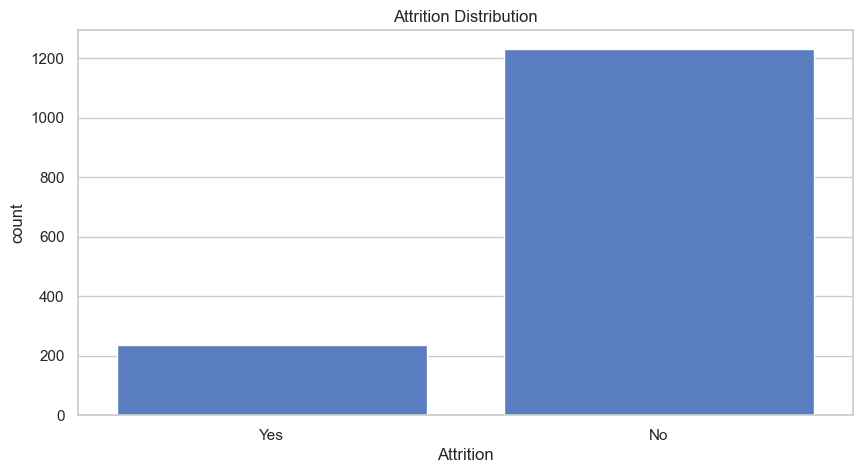

In [10]:
# Plot
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Distribution')
plt.show()

In [11]:
attrition_counts = df['Attrition'].value_counts()
ratio = attrition_counts['No'] / attrition_counts['Yes']
print(f"'No' / 'Yes' oranı: {ratio:.1f}x")
print()
if ratio > 3:
    print("WARNING: Significant class imbalance detected.")
    print("Consider using class_weight='balanced' or SMOTE during modelling.")

'No' / 'Yes' oranı: 5.2x

Consider using class_weight='balanced' or SMOTE during modelling.


The accuracy metric can be misleading. Now we can move on to variable analyses.

In [104]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'AttritionFlag']

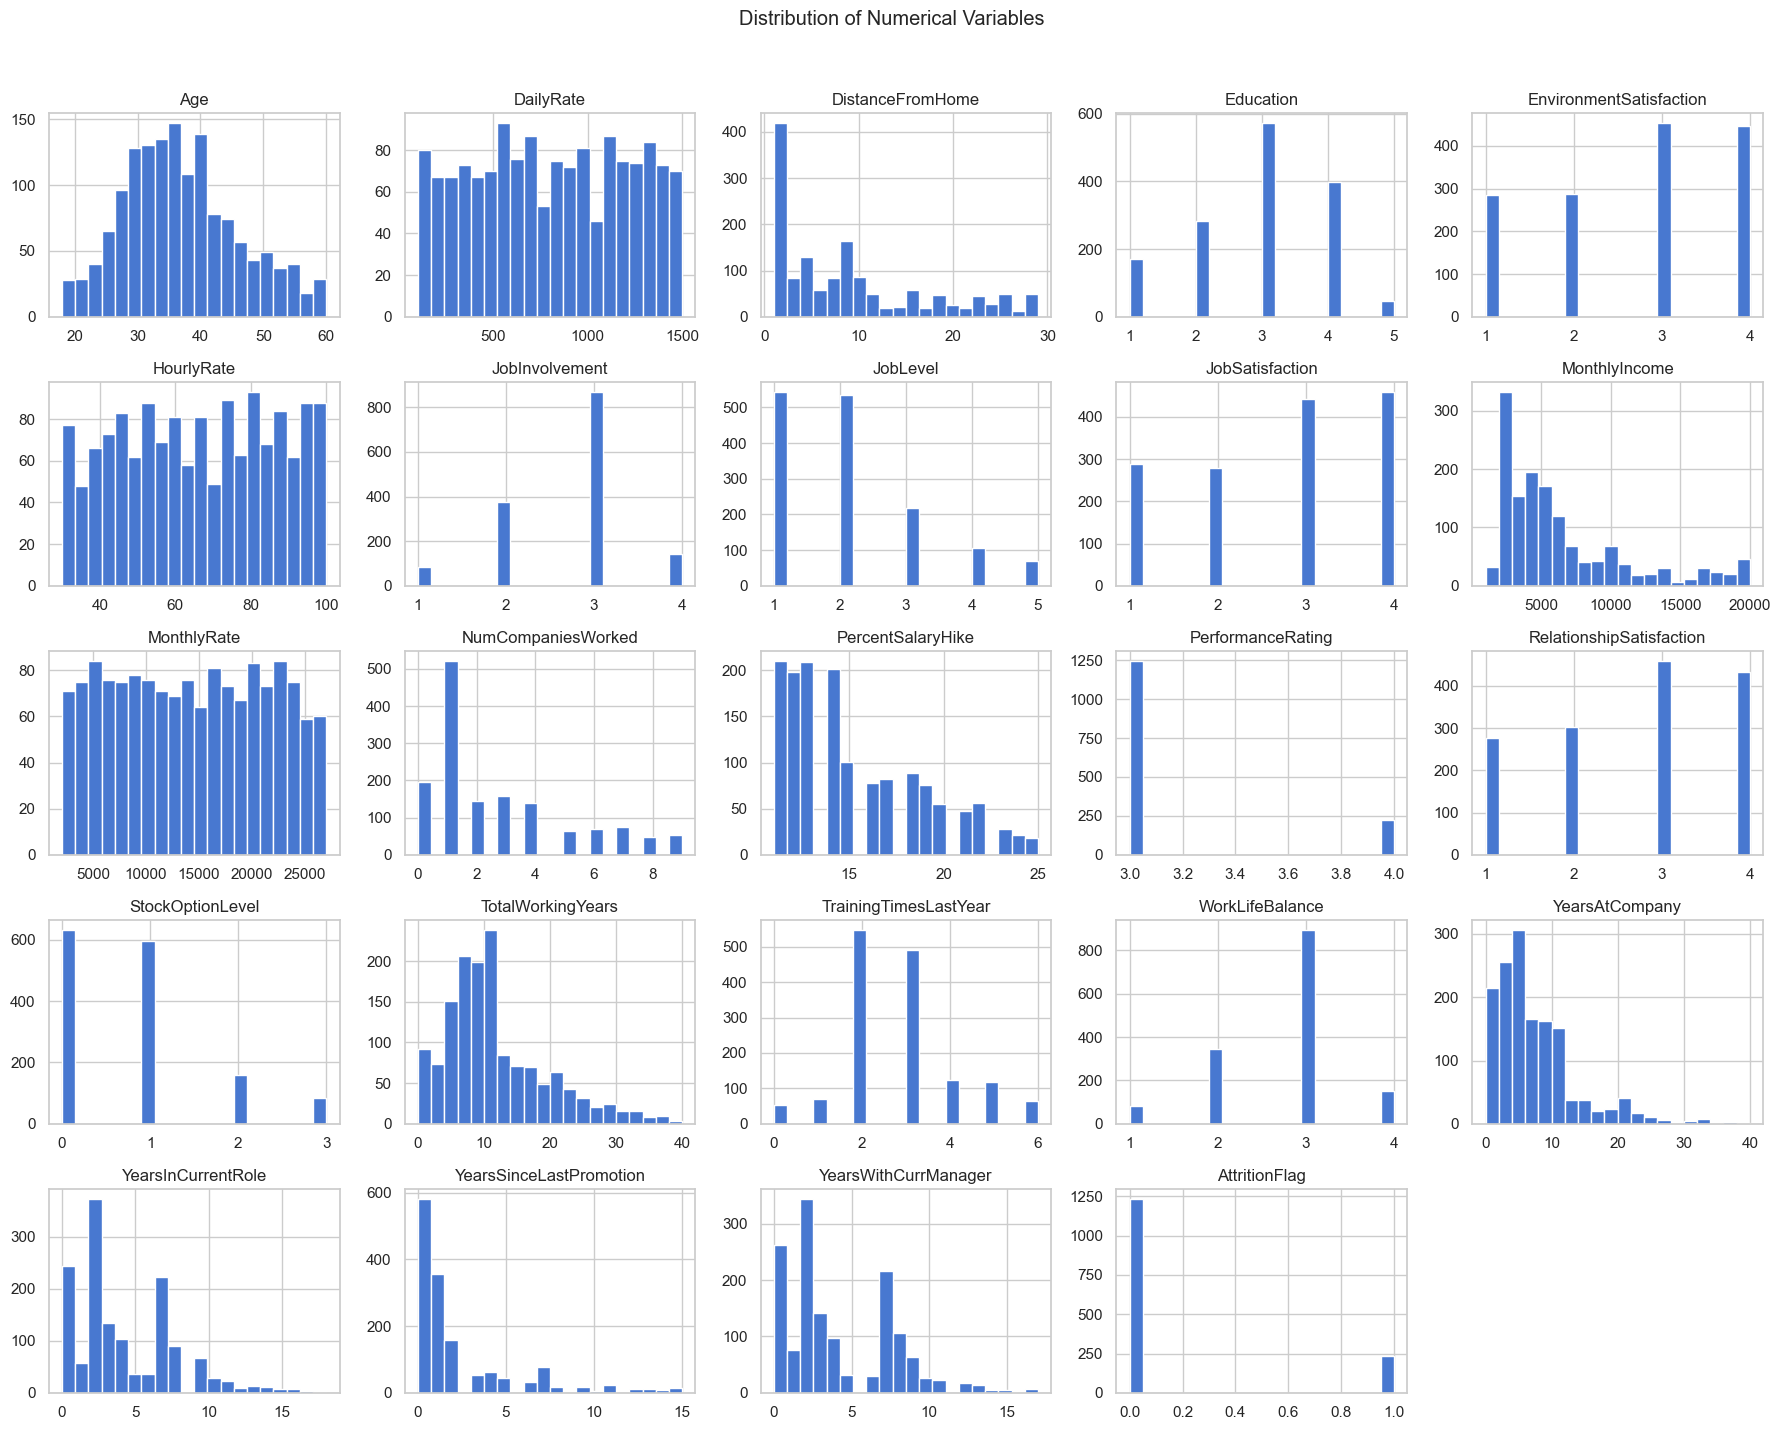

In [38]:
df[num_cols].hist(bins=20, figsize=(18, 14))
plt.suptitle('Distribution of Numerical Variables', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
df[num_cols].skew().sort_values(ascending=False)

YearsSinceLastPromotion     1.98
PerformanceRating           1.92
AttritionFlag               1.84
YearsAtCompany              1.76
MonthlyIncome               1.37
TotalWorkingYears           1.12
NumCompaniesWorked          1.03
JobLevel                    1.03
StockOptionLevel            0.97
DistanceFromHome            0.96
YearsInCurrentRole          0.92
YearsWithCurrManager        0.83
PercentSalaryHike           0.82
TrainingTimesLastYear       0.55
Age                         0.41
MonthlyRate                 0.02
DailyRate                  -0.00
HourlyRate                 -0.03
Education                  -0.29
RelationshipSatisfaction   -0.30
EnvironmentSatisfaction    -0.32
JobSatisfaction            -0.33
JobInvolvement             -0.50
WorkLifeBalance            -0.55
dtype: float64

In [15]:
cat_cols = df.select_dtypes(include=['str']).columns.tolist()
print(cat_cols)

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [16]:
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

Attrition: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
BusinessTravel: <StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str
Department: <StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
EducationField: <StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str
Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
JobRole: <StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str
MaritalStatus: <StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str
OverTime: <StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [17]:
df.groupby('OverTime')["Attrition"].value_counts(normalize=True).mul(100).round(1)

OverTime  Attrition
No        No          89.60
          Yes         10.40
Yes       No          69.50
          Yes         30.50
Name: proportion, dtype: float64

Attrition rate among employees who do not work overtime: 10.4%. Among those who do: 30.5% — nearly 3x higher. OverTime is one of the strongest individual signals in this dataset.

In [18]:
df.groupby("Attrition")["YearsSinceLastPromotion"].mean()

Attrition
No    2.23
Yes   1.95
Name: YearsSinceLastPromotion, dtype: float64

In [19]:
df.groupby('Attrition')['YearsSinceLastPromotion'].median()

Attrition
No    1.00
Yes   1.00
Name: YearsSinceLastPromotion, dtype: float64

Promotion delay alone is not a strong predictor of attrition. The mean and median gaps between leavers and stayers are negligible. However, this feature may become informative when combined with other risk factors — let's investigate the interaction.

In [39]:
# YearsSinceLastPromotion'ı gruplara bölelim
df['PromoGroup'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[-1, 0, 2, 5, 100],
    labels=['0 year', '1-2 years', '3-5 years', '5+ years']
)

# Her grupta ortalama maaş ve attrition oranı
promo_summary = df.groupby('PromoGroup', observed=True).agg(
    attrition_orani=('Attrition', lambda x: (x == 'Yes').mean() * 100),
    ort_maas=('MonthlyIncome', 'mean'),
    n=('Attrition', 'count')
).round(1)

print(promo_summary)

            attrition_orani  ort_maas    n
PromoGroup                                
0 year                18.90   5499.60  581
1-2 years             14.70   5945.70  516
3-5 years             10.10   8025.70  158
5+ years              16.30   9432.60  215


In [40]:
df.groupby(['PromoGroup', 'OverTime'], observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).unstack()

OverTime,No,Yes
PromoGroup,,
0 year,12.40,34.50
1-2 years,9.70,27.60
3-5 years,5.90,22.50
5+ years,10.30,31.70


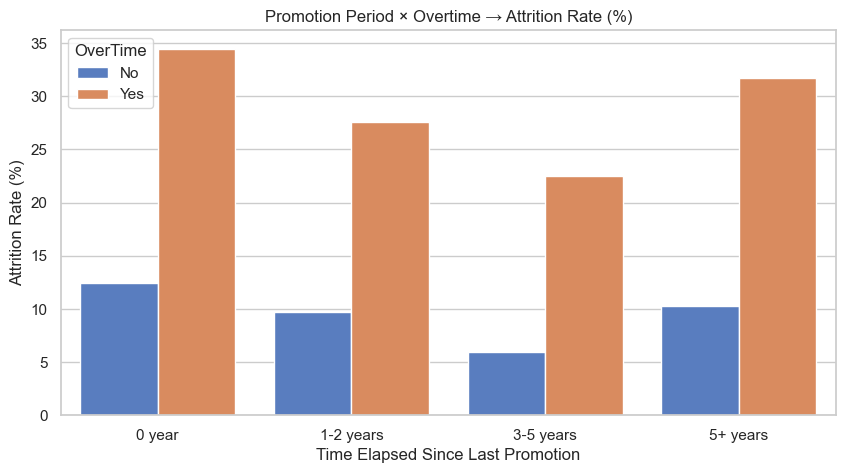

In [42]:
plot_data = df.groupby(['PromoGroup', 'OverTime'], observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).reset_index()
plot_data.columns = ['PromoGroup', 'OverTime', 'AttritionOrani']

sns.barplot(data=plot_data, x='PromoGroup', y='AttritionOrani', hue='OverTime')
plt.title('Promotion Period × Overtime → Attrition Rate (%)')
plt.xlabel('Time Elapsed Since Last Promotion')
plt.ylabel('Attrition Rate (%)')
plt.show()

OverTime dominates this interaction. Employees working overtime show consistently high attrition (22-34%) regardless of promotion history. That said, the "5+ years without promotion + OverTime=Yes" group stands out as the second-highest risk segment (31%). While promotion delay is a weak signal on its own, it becomes meaningful when paired with overtime — worth capturing as an interaction feature (OverTime_x_LongNoPromo) during feature engineering.

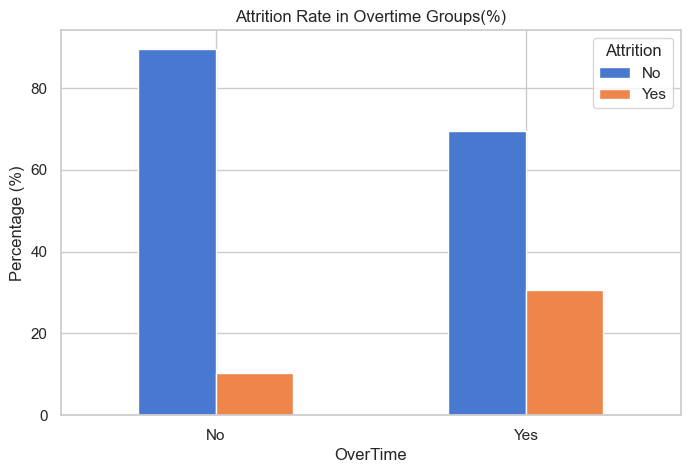

In [45]:
overtime_attrition = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).mul(100).round(1).unstack()

overtime_attrition.plot(kind='bar', figsize=(8, 5))
plt.title('Attrition Rate in Overtime Groups(%)')
plt.xlabel('OverTime')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()

şimdi gelirlere bakmak için MonthlyIncome kolonunu inceleyebiliriz

<Axes: xlabel='MonthlyIncome', ylabel='Density'>

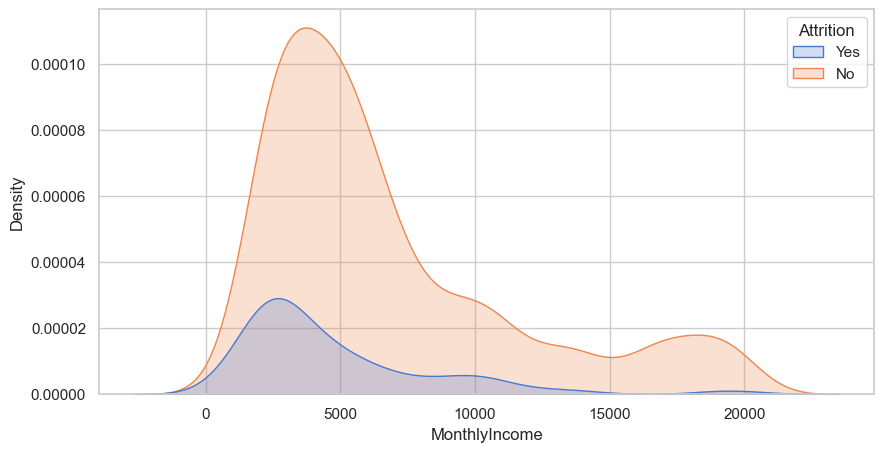

In [24]:
sns.kdeplot(data=df, x="MonthlyIncome", hue="Attrition", fill=True)

In [25]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.00,6832.74,4818.21,1051.00,3211.00,5204.00,8834.00,19999.00
Yes,237.00,4787.09,3640.21,1009.00,2373.00,3202.00,5916.00,19859.00


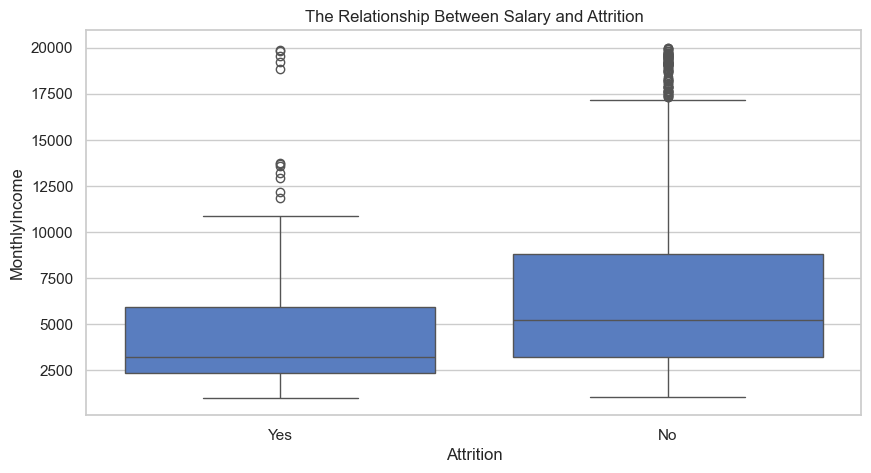

In [46]:
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('The Relationship Between Salary and Attrition')
plt.show()

Employees who leave earn ~30% less on average — a strong signal, but not the full story. High earners also appear among leavers, suggesting income alone isn't sufficient to explain attrition. MonthlyIncome likely interacts with other factors. Let's segment income into quartiles and examine these interactions.

In [27]:
df["IncomeBin"] = pd.qcut(df["MonthlyIncome"], 4)

In [28]:
pd.crosstab([df["IncomeBin"], df["OverTime"]],
            df["Attrition"],
            normalize="index")

Attrition                     No  Yes
IncomeBin          OverTime          
(1008.999, 2911.0] No       0.83 0.17
                   Yes      0.42 0.58
(2911.0, 4919.0]   No       0.90 0.10
                   Yes      0.74 0.26
(4919.0, 8379.0]   No       0.93 0.07
                   Yes      0.81 0.19
(8379.0, 19999.0]  No       0.93 0.07
                   Yes      0.82 0.18

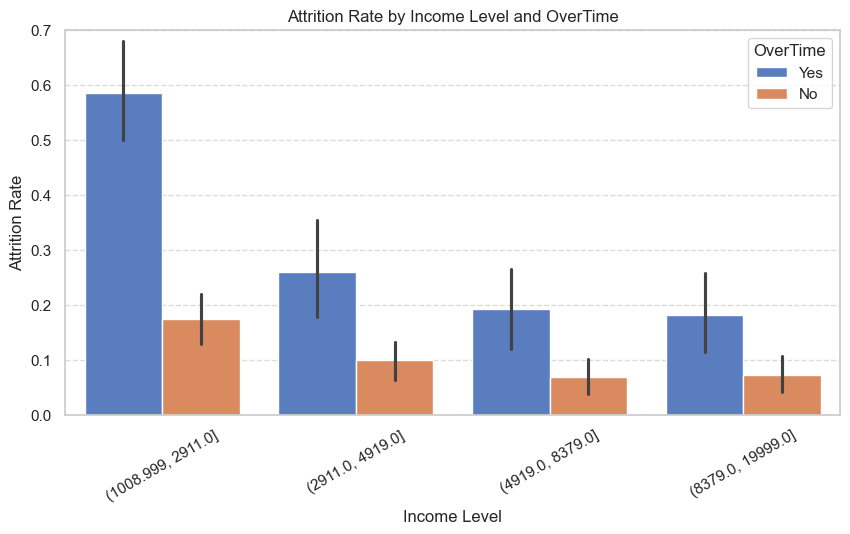

In [29]:
sns.barplot(
    x="IncomeBin",
    y="AttritionFlag",
    hue="OverTime",
    data=df
)

plt.ylim(0, 0.7)  # scale sabitle
plt.title("Attrition Rate by Income Level and OverTime")
plt.ylabel("Attrition Rate")
plt.xlabel("Income Level")
plt.legend(title="OverTime")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Low income + overtime is the most dangerous combination in this dataset. Attrition hits 58% in the lowest income quartile among overtime workers — and the effect fades as salary increases. This confirms a strong interaction between income and overtime, which will inform our feature engineering strategy.

In [30]:
pd.crosstab([df["IncomeBin"], df["JobRole"]],
            df["Attrition"],
            normalize="index")

Attrition                                      No  Yes
IncomeBin          JobRole                            
(1008.999, 2911.0] Human Resources           0.61 0.39
                   Laboratory Technician     0.71 0.29
                   Research Scientist        0.78 0.22
                   Sales Representative      0.56 0.44
(2911.0, 4919.0]   Healthcare Representative 0.95 0.05
                   Human Resources           0.92 0.08
                   Laboratory Technician     0.80 0.20
                   Manufacturing Director    0.90 0.10
                   Research Scientist        0.89 0.11
                   Sales Executive           0.88 0.12
                   Sales Representative      0.71 0.29
(4919.0, 8379.0]   Healthcare Representative 0.95 0.05
                   Human Resources           1.00 0.00
                   Laboratory Technician     0.88 0.12
                   Manufacturing Director    0.96 0.04
                   Research Scientist        0.93 0.07
                   Sales Executive           0.83 0.17
                   Sales Representative      1.00 0.00
(8379.0, 19999.0]  Healthcare Representative 0.89 0.11
                   Human Resources           0.60 0.40
                   Manager                   0.95 0.05
                   Manufacturing Director    0.91 0.09
                   Research Director         0.97 0.03
                   Research Scientist        1.00 0.00
                   Sales Executive           0.78 0.22

Now let's look at other potentially powerful variables: JobSatisfaction and Age

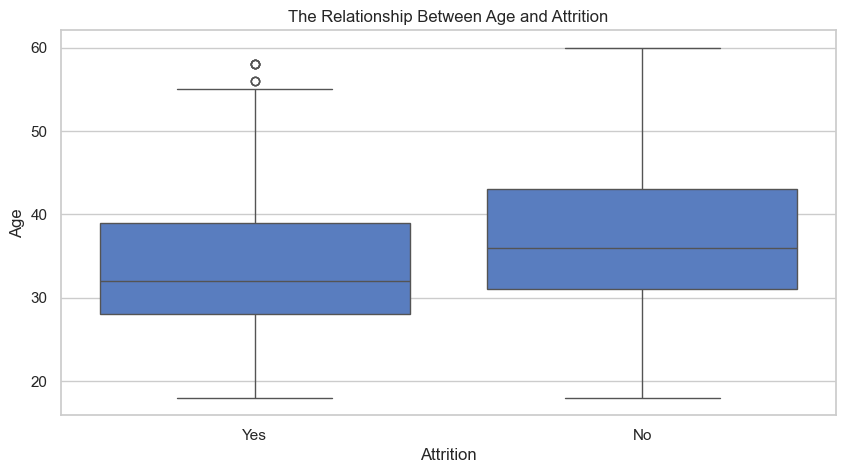

In [47]:
sns.boxplot(data=df, x='Attrition', y='Age')
plt.title('The Relationship Between Age and Attrition')
plt.show()

In [32]:
df.groupby("Attrition")["JobSatisfaction"].mean()

Attrition
No    2.78
Yes   2.47
Name: JobSatisfaction, dtype: float64

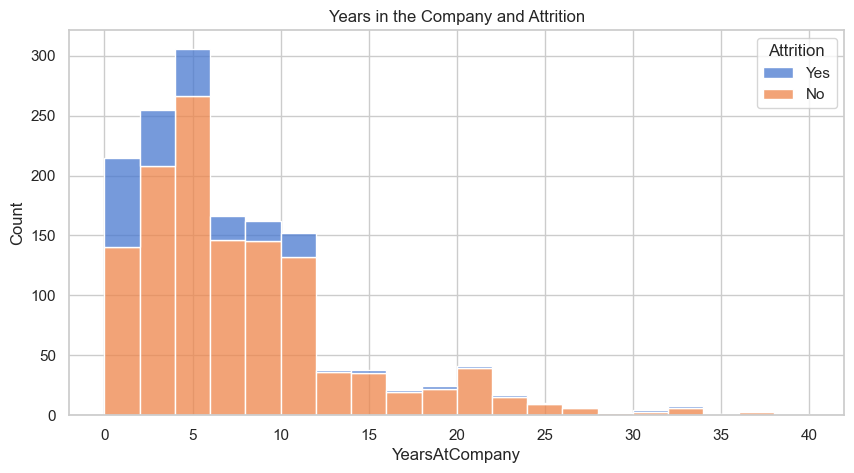

In [48]:
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', bins=20, multiple='stack')
plt.title('Years in the Company and Attrition')
plt.show()

Let's also look at the ratio instead of the raw numbers, because the number of employees in the group is different; without a ratio, saying "there are many turnovers" might actually just mean "there are many people."

In [34]:
df['YearsAtCompany_bin'] = pd.cut(df['YearsAtCompany'], bins=[0,2,5,10,20,40], labels=['0-2','3-5','6-10','11-20','20+'])

df.groupby('YearsAtCompany_bin', observed=True)['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100
).round(1)

YearsAtCompany_bin
0-2     28.90
3-5     13.80
6-10    12.30
11-20    6.70
20+     12.10
Name: Attrition, dtype: float64

In [35]:
df.groupby("Attrition")["DistanceFromHome"].mean()

Attrition
No     8.92
Yes   10.63
Name: DistanceFromHome, dtype: float64

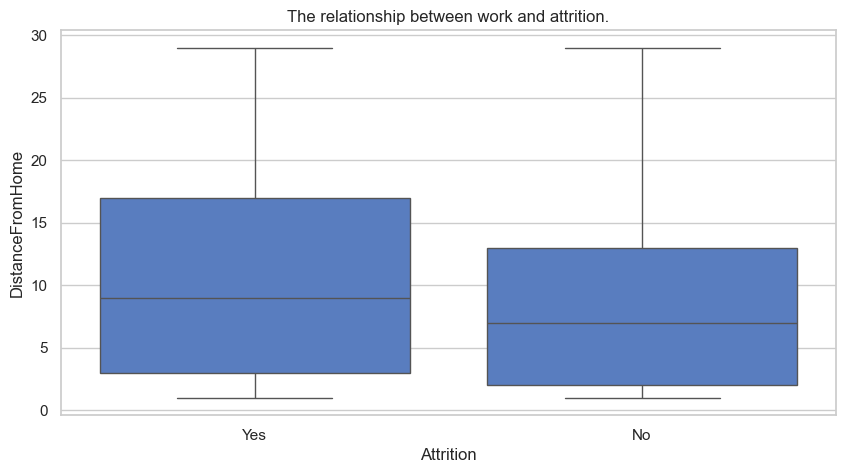

In [49]:
sns.boxplot(data=df,x="Attrition",y="DistanceFromHome")
plt.title("The relationship between work and attrition.")
plt.show()

Tek başına çok güçlü bir sinyal değil ama başka özelliklerle de birleşirse(hem uzak mesafe hem de fazla mesai) güçlü bir sinyal olabilir.

In [50]:
df.groupby('Attrition')[num_cols].mean()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag
Attrition,,,,,,,,,,,,,,,,,,,,,,,,
No,37.56,812.50,8.92,2.93,2.77,65.95,2.77,2.15,2.78,6832.74,14265.78,2.65,15.23,3.15,2.73,0.85,11.86,2.83,2.78,7.37,4.48,2.23,4.37,0.00
Yes,33.61,750.36,10.63,2.84,2.46,65.57,2.52,1.64,2.47,4787.09,14559.31,2.94,15.10,3.16,2.60,0.53,8.24,2.62,2.66,5.13,2.90,1.95,2.85,1.00


The analysis reveals that departing employees tend to have lower stock option levels, less overall work experience, and shorter seniority within the company and in their current role. These findings suggest that employees who have not yet fully integrated into the company are at higher risk of leaving.

In [102]:
df.groupby("JobLevel")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()

Attrition,No,Yes
JobLevel,,
1,73.70,26.30
2,90.30,9.70
3,85.30,14.70
4,95.30,4.70
5,92.80,7.20


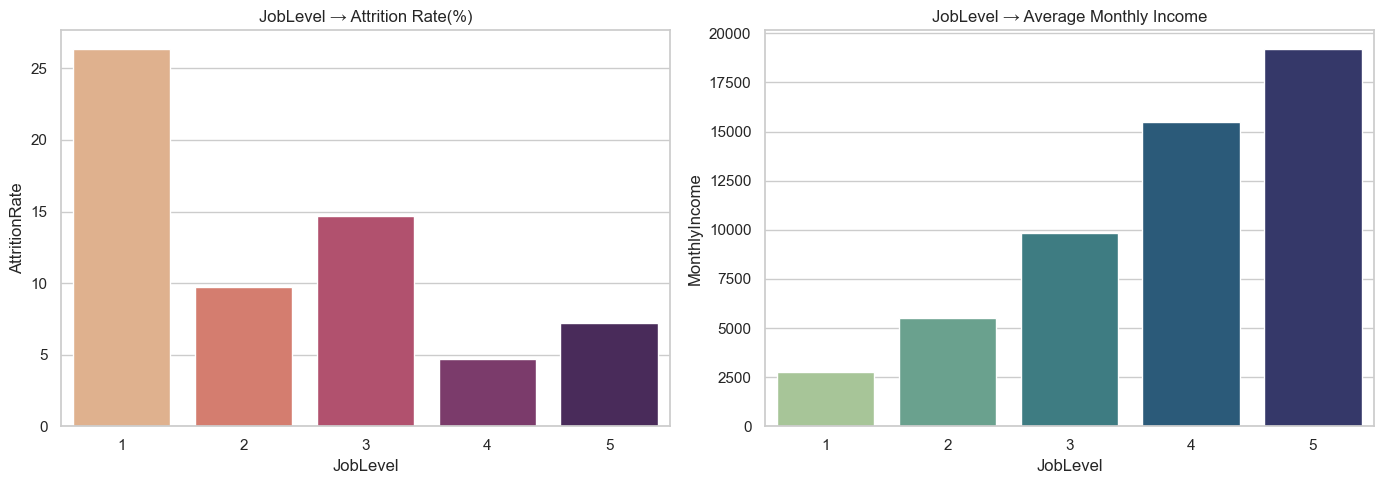

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

attrition_rate = (
    df.groupby("JobLevel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)
sns.barplot(data=attrition_rate, x="JobLevel", y="AttritionRate",
            hue="JobLevel", palette="flare", legend=False, ax=axes[0])
axes[0].set_title("JobLevel → Attrition Rate(%)")

income_by_level = df.groupby("JobLevel")["MonthlyIncome"].mean().reset_index()
sns.barplot(data=income_by_level, x="JobLevel", y="MonthlyIncome",
            hue="JobLevel", palette="crest", legend=False, ax=axes[1])
axes[1].set_title("JobLevel → Average Monthly Income")

plt.tight_layout()
plt.show()

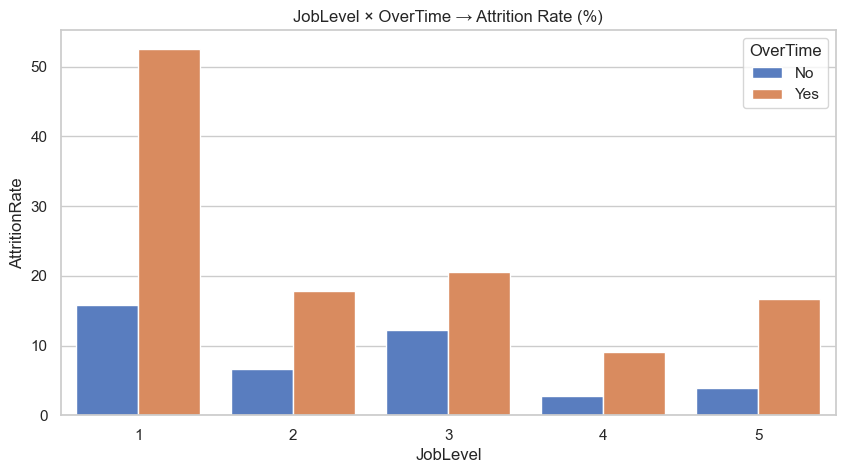

In [56]:
jl_ot_plot = (
    df.groupby(["JobLevel", "OverTime"])["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(1).reset_index(name="AttritionRate")
)
sns.barplot(data=jl_ot_plot, x="JobLevel", y="AttritionRate", hue="OverTime", palette="muted")
plt.title("JobLevel × OverTime → Attrition Rate (%)")
plt.show()

This is the strongest interaction in the entire EDA. Entry level employees working overtime leave at a staggering 52% rate. The effect diminishes sharply at higher levels (Level 4: 9%, Level 5: 17%). This pattern directly motivates the HighRisk_Flag composite feature we'll build during feature engineering combining JobLevel, OverTime, and income to capture this high-risk profile.

Now we can move on to categorical variables.

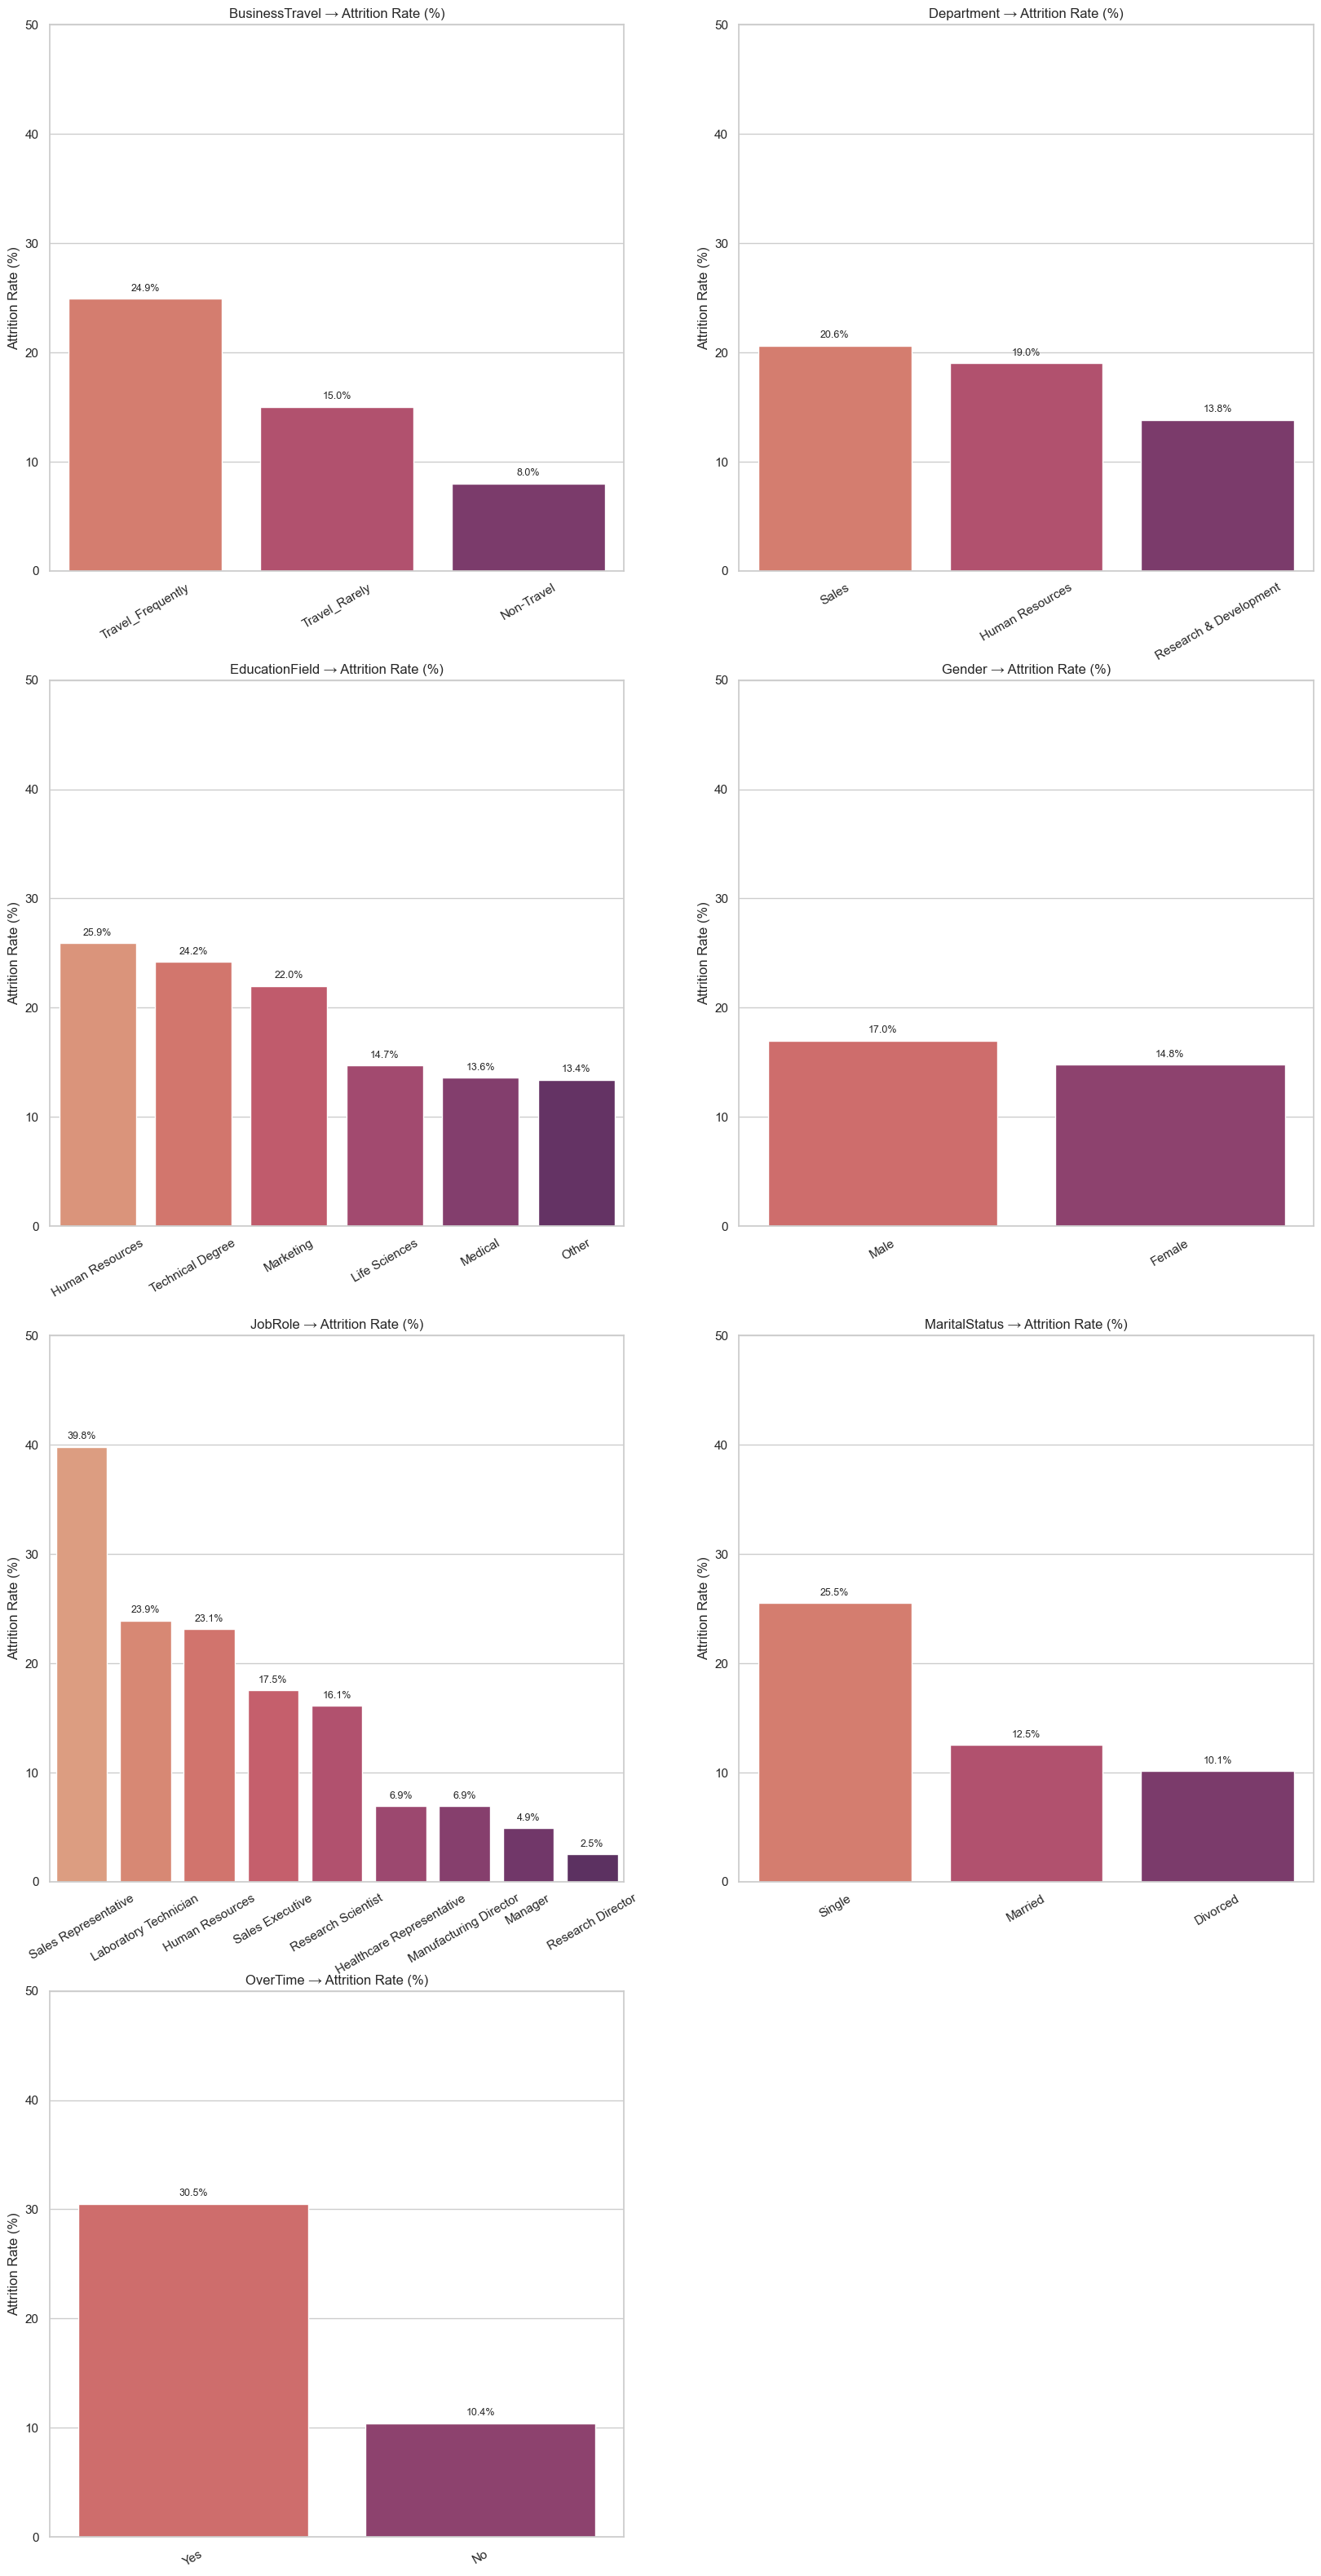

In [59]:
cat_cols_viz = ['BusinessTravel', 'Department', 'EducationField', 
                           'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

fig, axes = plt.subplots(4, 2, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(cat_cols_viz):
    rate = (
        df.groupby(col)['Attrition']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .round(1)
        .reset_index(name='AttritionRate')
        .sort_values('AttritionRate', ascending=False)
    )
    sns.barplot(data=rate, x=col, y='AttritionRate',
                hue=col, palette='flare', legend=False, ax=axes[i])
    axes[i].set_title(f'{col} → Attrition Rate (%)')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 50)
    axes[i].tick_params(axis='x', rotation=30)
    
    for bar in axes[i].patches:
        h = bar.get_height()
        if h > 0:
            axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                         f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

axes[-1].set_visible(False)  # 8

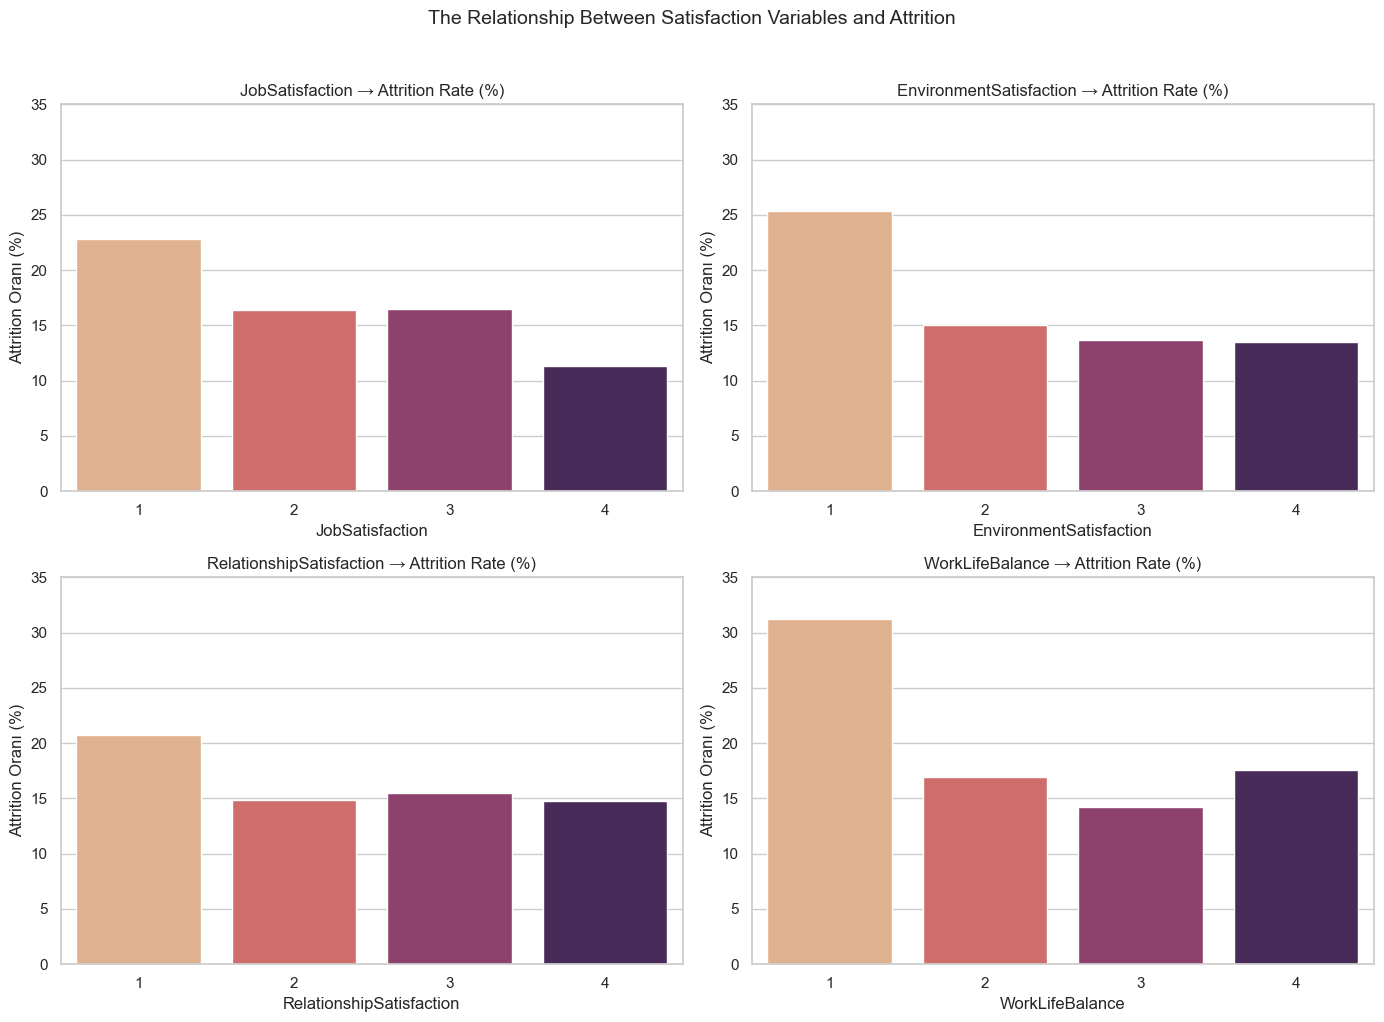

In [62]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(sat_cols):
    rate = (
        df.groupby(col)['Attrition']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .round(1)
        .reset_index(name='AttritionRate')
    )
    sns.barplot(data=rate, x=col, y='AttritionRate',
                hue=col, palette='flare', legend=False, ax=axes[i])
    axes[i].set_title(f'{col} → Attrition Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Attrition Oranı (%)')
    axes[i].set_ylim(0, 35)

plt.suptitle('The Relationship Between Satisfaction Variables and Attrition', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [107]:
df.groupby("Department")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()

Attrition,No,Yes
Department,,
Human Resources,81.00,19.00
Research & Development,86.20,13.80
Sales,79.40,20.60


There are relatively fewer employee turnovers in R&D departments.

In [108]:
df.groupby("JobRole")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()


Attrition,No,Yes
JobRole,,
Healthcare Representative,93.10,6.90
Human Resources,76.90,23.10
Laboratory Technician,76.10,23.90
Manager,95.10,4.90
Manufacturing Director,93.10,6.90
Research Director,97.50,2.50
Research Scientist,83.90,16.10
Sales Executive,82.50,17.50
Sales Representative,60.20,39.80


As you can see, lower-level jobs are more prone to turnover. Let's visualize this.

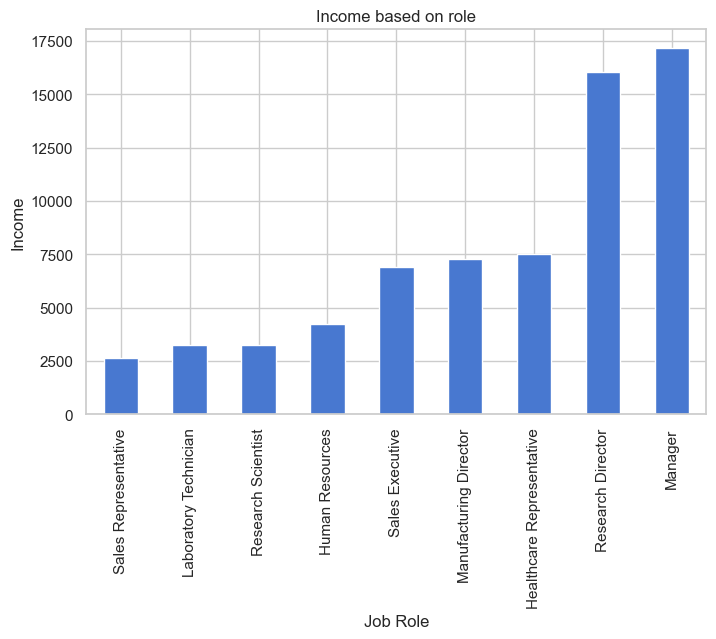

In [63]:
jobrole_income = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values()
jobrole_income.plot(kind='bar',figsize=(8, 5))
plt.title('Income based on role')
plt.xlabel('Job Role')
plt.ylabel('Income')
plt.show()

Actually, this graph combines two things we found earlier; low pay and low-level jobs together result in high turnover rates.

In [110]:
df.groupby("BusinessTravel")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.00,8.00
Travel_Frequently,75.10,24.90
Travel_Rarely,85.00,15.00


In [111]:
df.groupby("Gender")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()

Attrition,No,Yes
Gender,,
Female,85.20,14.80
Male,83.00,17.00


Looking at the other two categorical variables, frequent travelers are almost three times more likely to quit their jobs than those who never travel. However, when we look at gender, no significant difference is observed. From this point on, we can start looking at the correlation.

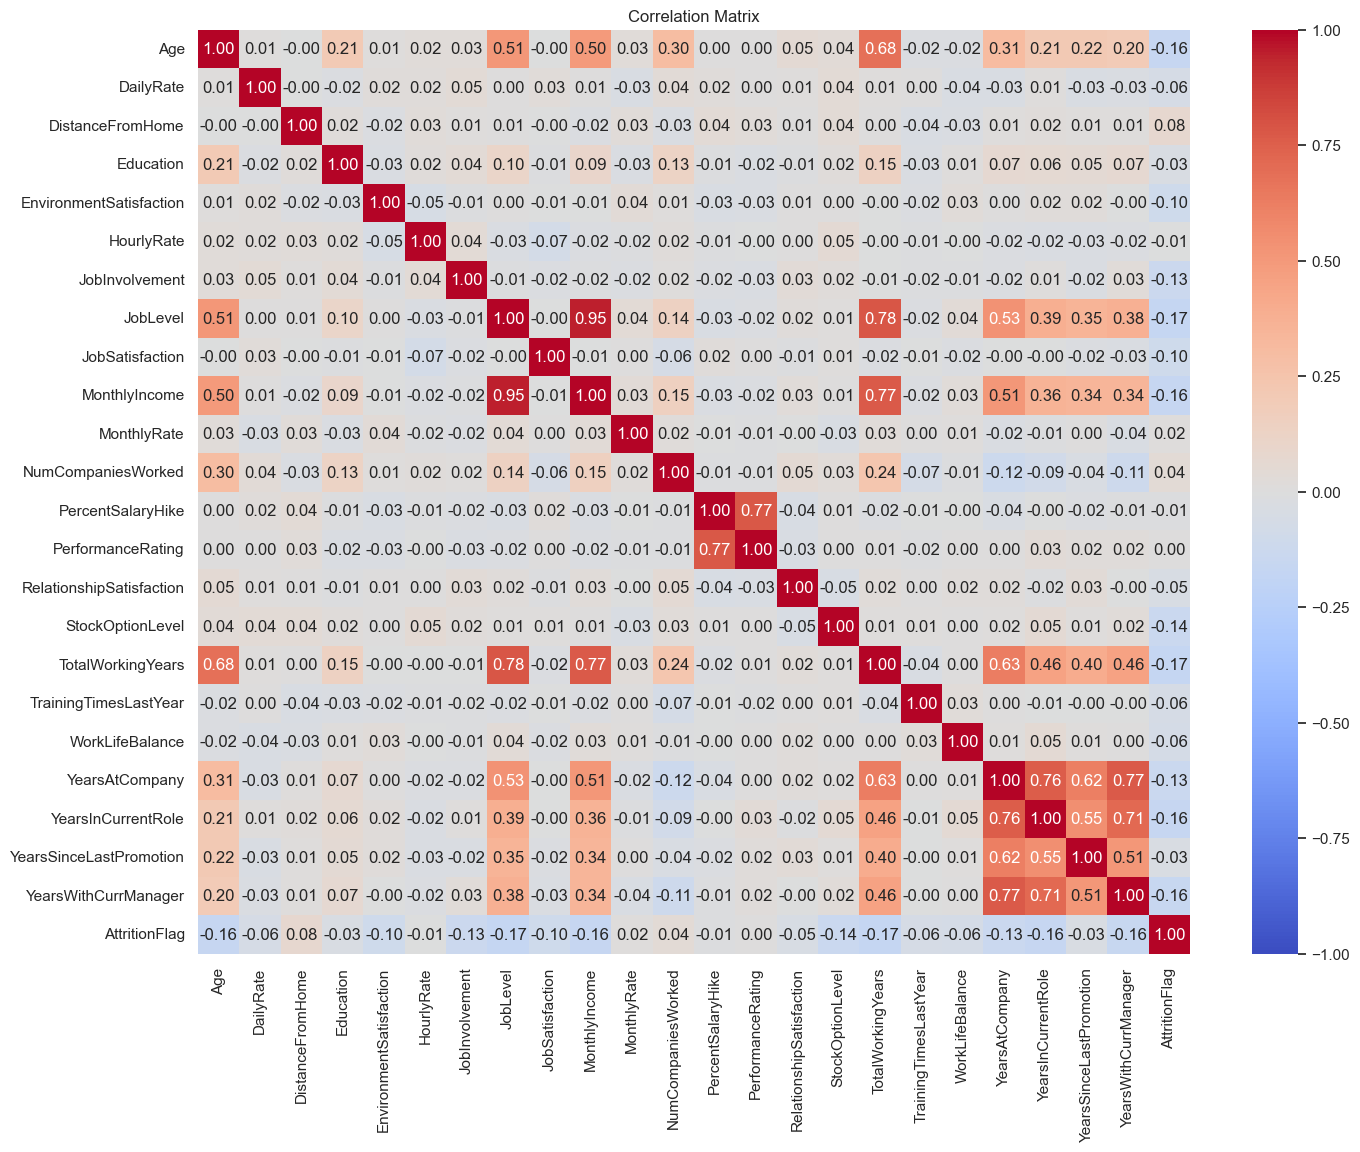

In [67]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

Two collinearity clusters stand out. MonthlyIncome, JobLevel, and TotalWorkingYears form one group (all proxies for seniority), while YearsAtCompany, YearsInCurrentRole, and YearsWithCurrManager form another (organizational tenure). This multicollinearity is worth noting for linear models. On the other hand, DistanceFromHome and some compensation-related features remain independent.

No single numeric feature correlates strongly with attrition (max |r| < 0.22). Seniority-related variables (JobLevel, TotalWorkingYears, MonthlyIncome, Age) show mild negative correlations — more experienced employees tend to stay. This reinforces what we've seen throughout the EDA: attrition is driven by feature interactions and categorical factors, not linear relationships. Time to translate these EDA insights into engineered features and build our prediction pipeline.Let's start by building a simple logistic regression model.

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report
import numpy as np

# ── 1. Feature set
X = df.drop(columns=['Attrition'])
y = (df['Attrition'] == 'Yes').astype(int)

# ── 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Column groups
ordinal_cols  = ['BusinessTravel']
ordinal_order = [['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']]
nominal_cols  = ['Department', 'JobRole', 'MaritalStatus', 'EducationField', 'Gender', 'OverTime']
numeric_cols  = [
    'Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
    'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',  # direkt ham hali
    'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# ── 4. Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
    ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),
    ('numeric', StandardScaler(), numeric_cols),
])

# ── 5. Pipeline (FE YOK)
pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# ── 6. Fit
pipeline_base.fit(X_train, y_train)

# ── 7. ROC-AUC
y_train_prob = pipeline_base.predict_proba(X_train)[:, 1]
y_test_prob  = pipeline_base.predict_proba(X_test)[:, 1]
print("Train ROC-AUC:", roc_auc_score(y_train, y_train_prob))
print("Test  ROC-AUC:", roc_auc_score(y_test,  y_test_prob))

# ── 8. Threshold optimizasyonu (aynı mantık)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_probs, val_labels = [], []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    pipeline_base.fit(X_tr, y_tr)
    val_probs.extend(pipeline_base.predict_proba(X_val)[:, 1])
    val_labels.extend(y_val)

precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"\nOptimal threshold (CV): {best_threshold:.3f}")

# ── 9. Final evaluation
pipeline_base.fit(X_train, y_train)
y_pred_opt = (pipeline_base.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))

Train ROC-AUC: 0.8732785310131311
Test  ROC-AUC: 0.8161771039710569

Optimal threshold (CV): 0.714
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       247
           1       0.57      0.45      0.50        47

    accuracy                           0.86       294
   macro avg       0.73      0.69      0.71       294
weighted avg       0.85      0.86      0.85       294



Let's add a few features to see if we can improve the results even further.

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report
import numpy as np

# ── 1. Feature set (ham veri — dışarıda hiçbir transform yok)
X = df.drop(columns=['Attrition'])
y = (df['Attrition'] == 'Yes').astype(int)

# ── 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Custom transformer: HighRisk_Flag + log(MonthlyIncome)
class RiskFeatureAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.income_q1_ = X["MonthlyIncome"].quantile(0.25)
        return self

    def transform(self, X):
        X = X.copy()
        X["MonthlyIncome_log"] = np.log1p(X["MonthlyIncome"])
        X["HighRisk_Flag"] = (
            (X["OverTime"] == "Yes") &
            (X["JobLevel"] <= 2) &
            (X["MonthlyIncome"] < self.income_q1_)
        ).astype(int)

        # just rates
        X["Income_per_TotalWorkingYear"] = X["MonthlyIncome"] / (X["TotalWorkingYears"] + 1)
        X["Income_per_JobLevel"] = X["MonthlyIncome"] / (X["JobLevel"] + 1)
        X["YearsInCurrentRole_ratio"] = X["YearsInCurrentRole"] / (X["YearsAtCompany"] + 1)
        X["YearsSinceLastPromotion_ratio"] = X["YearsSinceLastPromotion"] / (X["YearsAtCompany"] + 1)
        X["YearsWithCurrManager_ratio"] = X["YearsWithCurrManager"] / (X["YearsAtCompany"] + 1)
        ot = (X["OverTime"] == "Yes").astype(int)
        income_log = np.log1p(X["MonthlyIncome"])

        X["OverTime_x_Income"] = ot * income_log
        X["OverTime_x_Distance"] = ot * X["DistanceFromHome"]
        X["JobLevel_x_Years"] = X["JobLevel"] * X["TotalWorkingYears"]

        return X.drop(columns=["MonthlyIncome"])
# ── 4. Column groups
ordinal_cols  = ['BusinessTravel']
ordinal_order = [['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']]
nominal_cols  = ['Department', 'JobRole', 'MaritalStatus', 'EducationField', 'Gender', 'OverTime']
numeric_cols  = [
'Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome_log',
'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
'HighRisk_Flag','Income_per_TotalWorkingYear','Income_per_JobLevel',
'YearsInCurrentRole_ratio','YearsSinceLastPromotion_ratio','YearsWithCurrManager_ratio','OverTime_x_Income',
'OverTime_x_Distance', 'JobLevel_x_Years']

# ── 5. Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
    ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),
    ('numeric', StandardScaler(), numeric_cols),
])

# ── 6. Pipeline
pipeline_v2 = Pipeline(steps=[
    ('feature_engineering', RiskFeatureAdder()),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# ── 7. Fit
pipeline_v2.fit(X_train, y_train)

# ── 8. ROC-AUC
y_train_prob = pipeline_v2.predict_proba(X_train)[:, 1]
y_test_prob  = pipeline_v2.predict_proba(X_test)[:, 1]
print("Train ROC-AUC:", roc_auc_score(y_train, y_train_prob))
print("Test  ROC-AUC:", roc_auc_score(y_test,  y_test_prob))

# ── 9. Threshold optimizasyonu — CV üzerinden (test leak yok)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_probs, val_labels = [], []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    pipeline_v2.fit(X_tr, y_tr)
    val_probs.extend(pipeline_v2.predict_proba(X_val)[:, 1])
    val_labels.extend(y_val)

precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"\nOptimal threshold (CV): {best_threshold:.3f}")

# ── 10. Final model — tüm train ile yeniden fit et, test'te raporla
pipeline_v2.fit(X_train, y_train)
y_pred_opt = (pipeline_v2.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))

# different threshold trials
y_pred_06 = (pipeline_v2.predict_proba(X_test)[:, 1] >= 0.6).astype(int)
print("Threshold 0.6")
print(classification_report(y_test, y_pred_06))

y_pred_05 = (pipeline_v2.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
print("Threshold 0.5")
print(classification_report(y_test, y_pred_05))

Train ROC-AUC: 0.8855449983986334
Test  ROC-AUC: 0.8367645792057886

Optimal threshold (CV): 0.715
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       247
           1       0.61      0.47      0.53        47

    accuracy                           0.87       294
   macro avg       0.76      0.71      0.73       294
weighted avg       0.86      0.87      0.86       294

Threshold 0.6
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       247
           1       0.52      0.64      0.57        47

    accuracy                           0.85       294
   macro avg       0.72      0.76      0.74       294
weighted avg       0.86      0.85      0.85       294

Threshold 0.5
              precision    recall  f1-score   support

           0       0.93      0.81      0.87       247
           1       0.42      0.70      0.52        47

    accuracy                           0.80       294
 

In [91]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob  = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {name} =====")
    print("Train ROC-AUC:", roc_auc_score(y_train, y_train_prob))
    print("Test  ROC-AUC:", roc_auc_score(y_test,  y_test_prob))

# karşılaştır
evaluate_model(pipeline_base, X_train, X_test, y_train, y_test, "BASE (No FE)")
evaluate_model(pipeline_v2,   X_train, X_test, y_train, y_test, "WITH FE")


===== BASE (No FE) =====
Train ROC-AUC: 0.8732785310131311
Test  ROC-AUC: 0.8161771039710569

===== WITH FE =====
Train ROC-AUC: 0.8855449983986334
Test  ROC-AUC: 0.8367645792057886


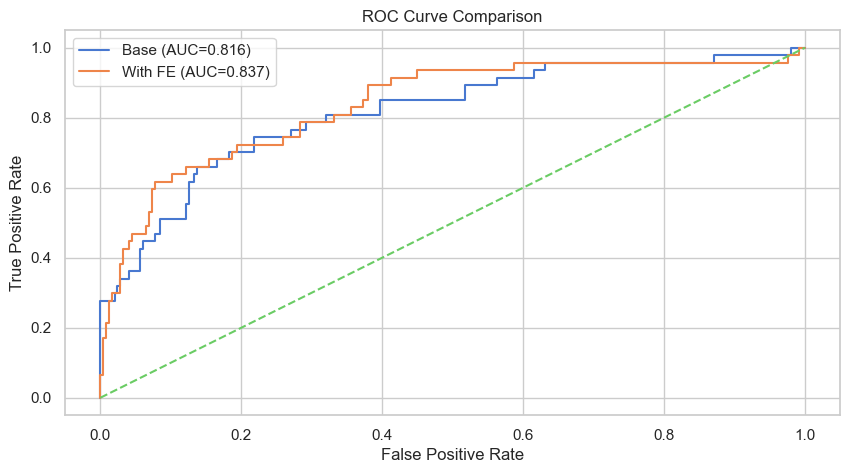

In [97]:
from sklearn.metrics import roc_curve

base_probs = pipeline_base.predict_proba(X_test)[:,1]
fe_probs   = pipeline_v2.predict_proba(X_test)[:,1]

fpr_base, tpr_base, _ = roc_curve(y_test, base_probs)
fpr_fe, tpr_fe, _     = roc_curve(y_test, fe_probs)

plt.figure()
plt.plot(fpr_base, tpr_base, label=f'Base (AUC={base_auc:.3f})')
plt.plot(fpr_fe, tpr_fe, label=f'With FE (AUC={fe_auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

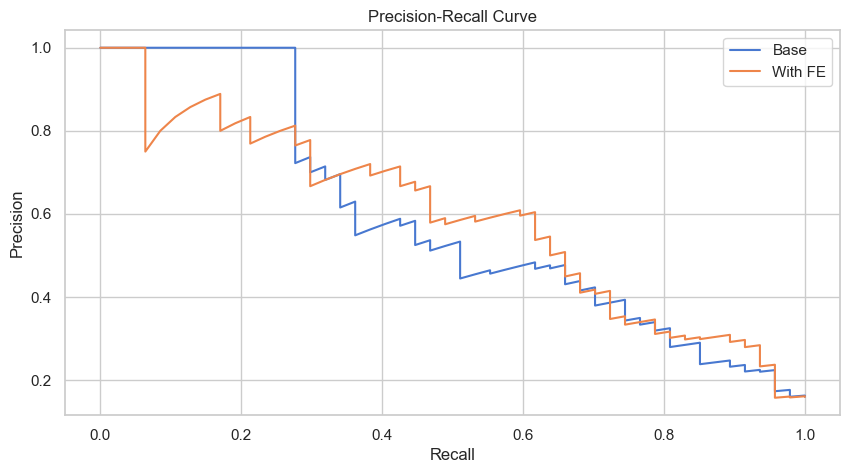

In [96]:
from sklearn.metrics import precision_recall_curve

prec_base, rec_base, _ = precision_recall_curve(y_test, base_probs)
prec_fe, rec_fe, _     = precision_recall_curve(y_test, fe_probs)

plt.figure()
plt.plot(rec_base, prec_base, label='Base')
plt.plot(rec_fe, prec_fe, label='With FE')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## 📊 Baseline vs Feature Engineering

| Model | ROC-AUC |
|------|--------|
| Baseline | 0.82 |
| With Feature Engineering | 0.83+ |

Feature engineering led to a measurable improvement in model performance, indicating that feature representation was more impactful than model complexity.

In [75]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__max_depth':        [2, 3, 4],
    'model__n_estimators':     [100, 200, 300],
    'model__learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'model__subsample':        [0.6, 0.7, 0.8],
    'model__colsample_bytree': [0.6, 0.7, 0.8],
    'model__reg_alpha':        [0, 0.1, 0.5, 1.0],
    'model__reg_lambda':       [1.0, 2.0, 3.0],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma':            [0, 0.5, 1.0],
}

pipeline_xgb_search = Pipeline(steps=[
    ('feature_engineering', RiskFeatureAdder()),
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=5,
    ))
])

search = RandomizedSearchCV(
    pipeline_xgb_search,
    param_distributions=param_dist,
    n_iter=50,                    # 50 rastgele kombinasyon dene
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,                    # tüm CPU'ları kullan
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

# Test seti sonucu
y_test_prob = search.best_estimator_.predict_proba(X_test)[:, 1]
print("Test  AUC:  ", roc_auc_score(y_test, y_test_prob))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__subsample': 0.6, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.5, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.6}
Best CV AUC: 0.8221922673164993
Test  AUC:   0.8174692049272116


In [90]:
# Final pipeline with optimal parameters.
pipeline_xgb_final = search.best_estimator_

# Threshold optimization — via CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_probs, val_labels = [], []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    pipeline_xgb_final.fit(X_tr, y_tr)
    val_probs.extend(pipeline_xgb_final.predict_proba(X_val)[:, 1])
    val_labels.extend(y_val)

precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (CV): {best_threshold:.3f}")

# Final model — refitted with all train included.
pipeline_xgb_final.fit(X_train, y_train)
y_pred_opt = (pipeline_xgb_final.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))

Optimal threshold (CV): 0.485
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       247
           1       0.50      0.57      0.53        47

    accuracy                           0.84       294
   macro avg       0.71      0.73      0.72       294
weighted avg       0.85      0.84      0.84       294



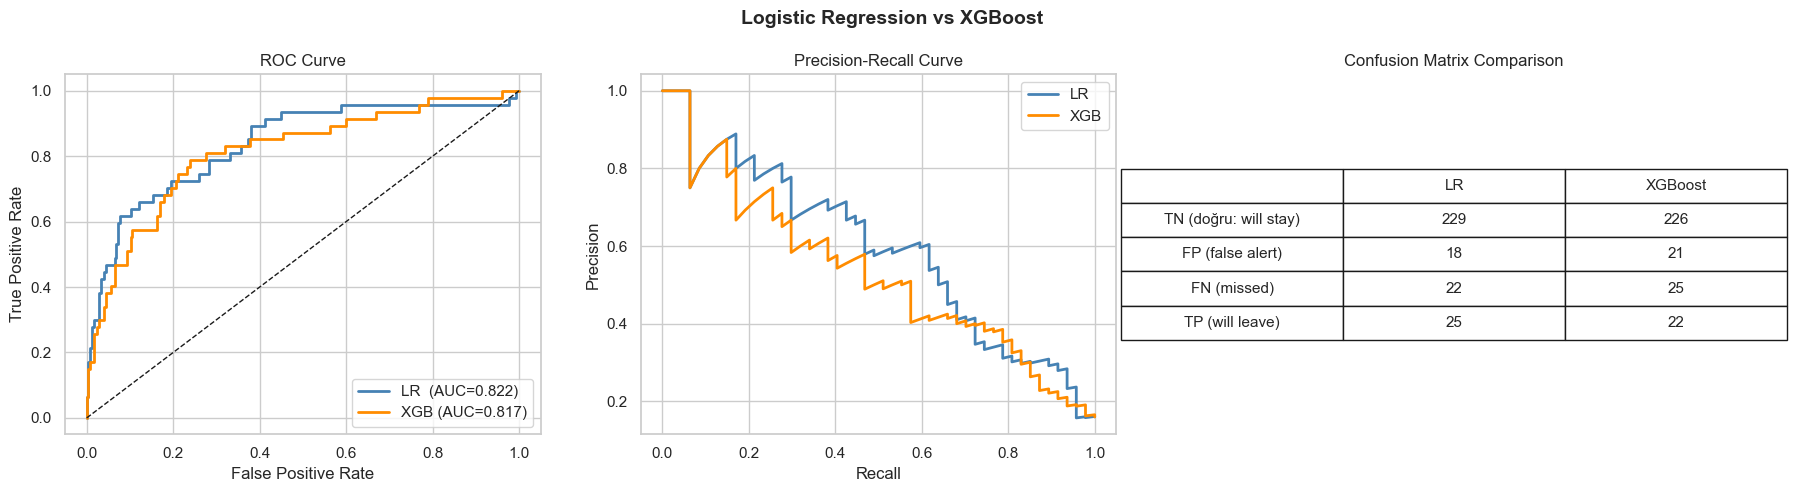

In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
import numpy as np
# ── Get predicted probabilities from both models
pipeline_v2.fit(X_train, y_train)
y_test_prob_lr = pipeline_v2.predict_proba(X_test)[:, 1]

pipeline_xgb_final.fit(X_train, y_train)
y_test_prob_xgb = pipeline_xgb_final.predict_proba(X_test)[:, 1]
# Predictions with treshold
lr_threshold  = 0.682
xgb_threshold = 0.577

y_pred_lr  = (y_test_prob_lr  >= lr_threshold).astype(int)
y_pred_xgb = (y_test_prob_xgb >= xgb_threshold).astype(int)

#ROC curve data
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_test_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_prob_xgb)

# PR curve data
prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, y_test_prob_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_test_prob_xgb)

# Confusion matrix data
cm_lr  = confusion_matrix(y_test, y_pred_lr)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Graph
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistic Regression vs XGBoost", fontsize=14, fontweight='bold')

# 1) ROC Curve
ax = axes[0]
ax.plot(fpr_lr,  tpr_lr,  label='LR  (AUC=0.822)', color='steelblue', lw=2)
ax.plot(fpr_xgb, tpr_xgb, label='XGB (AUC=0.817)', color='darkorange', lw=2)
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# 2) PR Curve
ax = axes[1]
ax.plot(rec_lr,  prec_lr,  label='LR',  color='steelblue', lw=2)
ax.plot(rec_xgb, prec_xgb, label='XGB', color='darkorange', lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()

# 3) Confusion Matrix 
ax = axes[2]
ax.axis('off')

# 4)Show both CMs as a table.
labels = ['TN', 'FP', 'FN', 'TP']
lr_vals  = cm_lr.ravel()
xgb_vals = cm_xgb.ravel()

table_data = [
    ['', 'LR', 'XGBoost'],
    ['TN (doğru: will stay)', lr_vals[0], xgb_vals[0]],
    ['FP (false alert)',   lr_vals[1], xgb_vals[1]],
    ['FN (missed)',      lr_vals[2], xgb_vals[2]],
    ['TP (will leave)', lr_vals[3], xgb_vals[3]],
]

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.2)
ax.set_title('Confusion Matrix Comparison')

plt.tight_layout()
plt.savefig('lr_vs_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

/Users/ulasmerttoy/Desktop/machine learning projects/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


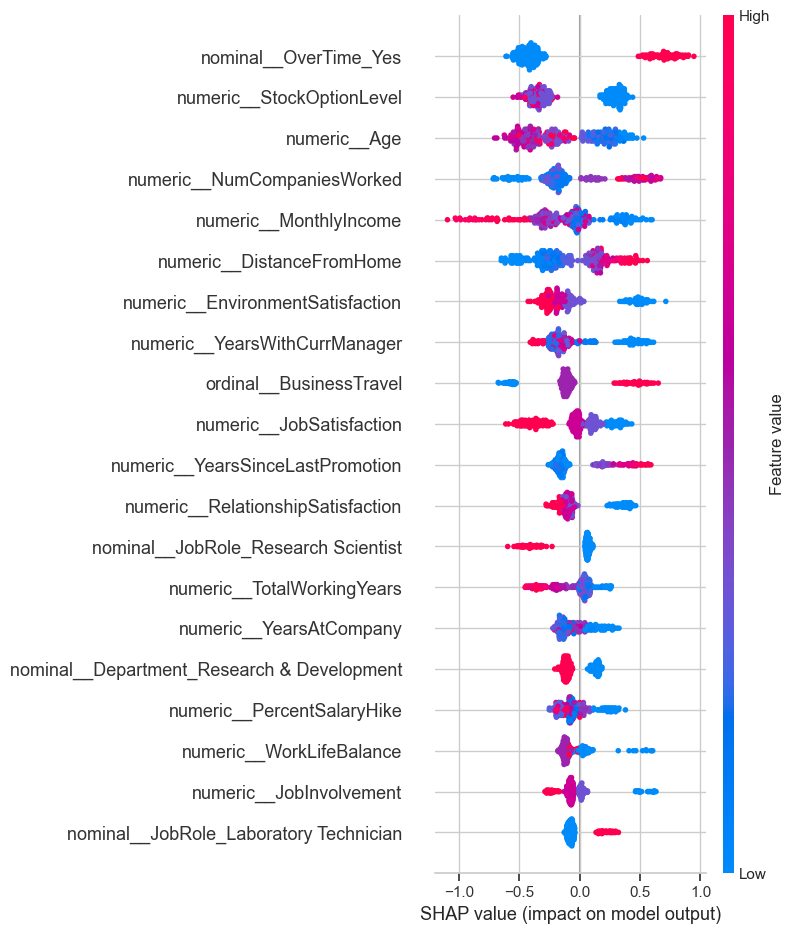

In [130]:
import shap

# Extract the model step and pass data through feature engineering + preprocessing
X_test_transformed = pipeline_xgb_final[:-1].transform(X_test)

# Get feature names
feature_names = (
    pipeline_xgb_final['preprocessor']
    .get_feature_names_out()
)

# SHAP explainer
explainer = shap.TreeExplainer(pipeline_xgb_final['model'])
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

In [80]:
#Find the highest-risk employee.
y_test_prob_xgb = pipeline_xgb_final.predict_proba(X_test)[:, 1]
riskiest_idx = np.argmax(y_test_prob_xgb)

print(f"Employee index: {riskiest_idx}")
print(f"Attrition probability: {y_test_prob_xgb[riskiest_idx]:.2%}")
print(f"Actually left: {'Yes' if y_test.iloc[riskiest_idx] == 1 else 'No'}")
print("\nEmployee profile:")
print(X_test.iloc[riskiest_idx])

Employee index: 200
Attrition probability: 97.88%
Actually left: Yes

Employee profile:
Age                                           19
BusinessTravel                     Travel_Rarely
DailyRate                                    419
Department                                 Sales
DistanceFromHome                              21
Education                                      3
EducationField                             Other
EnvironmentSatisfaction                        4
Gender                                      Male
HourlyRate                                    37
JobInvolvement                                 2
JobLevel                                       1
JobRole                     Sales Representative
JobSatisfaction                                2
MaritalStatus                             Single
MonthlyIncome                               2121
MonthlyRate                                 9947
NumCompaniesWorked                             1
OverTime                      

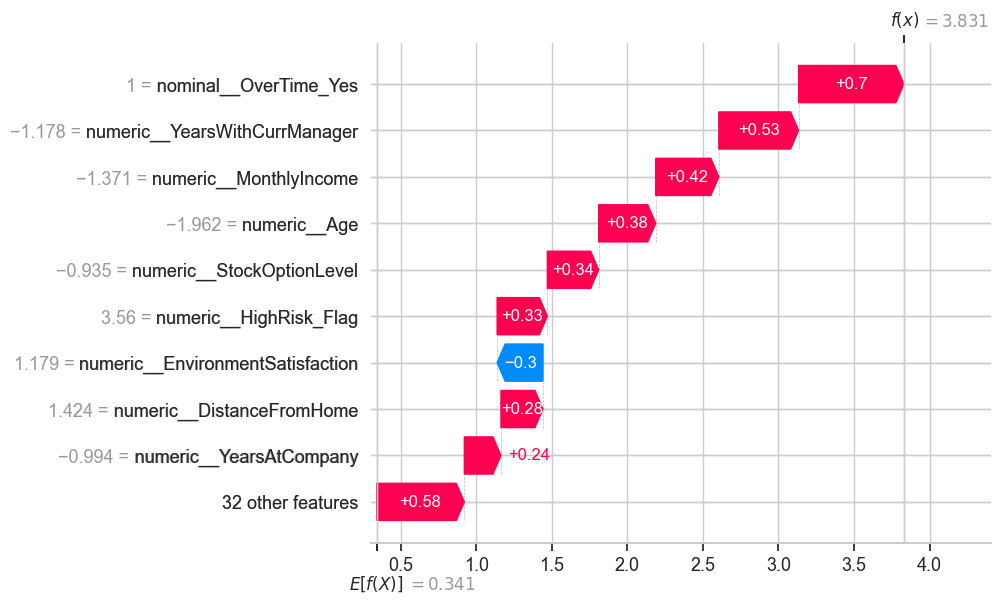

In [132]:
# ── Waterfall plot
shap_values_single = explainer.shap_values(X_test_transformed[riskiest_idx:riskiest_idx+1])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_single[0],
        base_values=explainer.expected_value,
        data=X_test_transformed[riskiest_idx],
        feature_names=list(feature_names)
    )
)

## Summary

- **Best model:** Logistic Regression (ROC-AUC: 0.822) — outperformed tuned XGBoost on this small dataset, reinforcing that complexity doesn't always win on tabular data with limited samples.
- **Key insight:** Attrition is not driven by any single feature. The strongest predictors emerge from interactions — particularly OverTime × JobLevel × Income.
- **Custom feature:** `HighRisk_Flag` captures the riskiest employee profile (overtime + entry-level + low income) inside a leak-free sklearn transformer.
- **Threshold optimization:** CV-based threshold tuning improved minority-class detection without touching the test set.
- **Explainability:** SHAP values provide both global feature importance and individual-level explanations for HR decision-makers.